In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
jr.init_cluster()

#parameters
nx = 128
ny = 128
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 100
t_end = 10.0
cfl_safety = 0.5 
spatial_dimensions=3
snap_path="data/engine_test_sharding"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
kgrid = jr.setup_kgrids(params)

def test_init(x,y,z):
    phi = (jnp.cos(x+1.4) + jnp.cos(y+0.5)) * jnp.sin(z)
    psi = (jnp.cos(2.0*x+2.3) + jnp.cos(y + 4.1)) * jnp.cos(z)
    return jnp.stack([phi,psi],axis=0)

state=jr.initialize(test_init,params)

nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock)) #not actually using this, since we just want to simulate for a fixed 100 steps
nblock = 1

end_state=jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr,save=False)

rmhd-solver has initialized jax in 64bit precision.


Running in local mode. Total devices: 4
nblock estimate: 887
0.011262246510618967
0.022515626055961843
0.03375930163588339
0.044995889934807534
0.05622756474570395
0.06744935557061925
0.07866362239893404
0.0898725353393588
0.10107494789961104
0.11226741818694348
0.12345111446479795
0.13462711756996948
0.14579227489533422
0.15694469108211165
0.1680860933844684
0.17921829716501775
0.19034235729181262
0.2014557915501214
0.21255801044640008
0.2236477563697947
0.23472226022302106
0.2457802676105417
0.2568237243507131
0.26785439738782973
0.2788719087019882
0.2898730573168049
0.3008590214216778
0.31183095201850397
0.3227890653673609
0.33372948873607955
0.3446543919026743
0.3555618022306787
0.3664492591682521
0.377318781773004
0.3881724666997064
0.3990118428402486
0.40982313860879543
0.4205974049781994
0.4313279146972747
0.44202003766226955
0.4526735158006913
0.4632758198233319
0.4738296616338823
0.4843369768416136
0.4947936901586559
0.5052039022753398
0.5155694522566762
0.5258760744993208
0.5

In [2]:
vort=ft.irfft2(-kgrid.ksq()*end_state.fields[0,:,:,:])

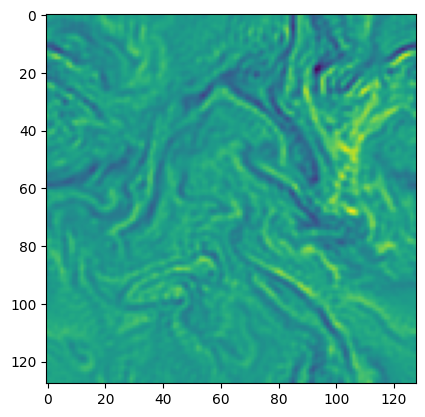

In [3]:
plt.imshow(vort[39,:,:])

In [5]:
from jax.debug import visualize_array_sharding

# Slicing a 2D plane (index 0 of nfields, all nz, index 0 of nkx, all nky)
visualize_array_sharding(end_state.fields[:, :, 0, 0])

In [ ]:
import jax
import jax_rmhd.timestepping as ts
from functools import partial
stepper,scheme=ts.get_scheme("lsrk33")
# 1. Create a tiny test function that mirrors your real-space to k-space FFT pipeline
@partial(jax.jit,static_argnums=(2,3,4,5))
def check_hlo(state,kgrid,params,nblock,scheme,stepper):
    # This matches the rfft2 behavior on the last two axes
    return jr.run.block_of_steps(state,kgrid,params,nblock,scheme,stepper)

# 2. Lower and compile using your actual sharded array as a template
# (Assuming `sample_field` is an array already sharded with fields_sharding)
lowered = check_hlo.lower(state,kgrid,params,nblock,scheme,stepper)
compiled = lowered.compile()

# 3. Extract the text representation of XLA's optimized execution plan
hlo_text = compiled.as_text()

# 4. Search for cross-device communication operations
communication_ops = ["all-to-all", "all-gather", "reduce-scatter", "collective-permute"]
has_communication = False

print("Checking XLA HLO for cross-device communication...")
for op in communication_ops:
    if op in hlo_text.lower():
        print(f"⚠️ FOUND: {op} is happening!")
        has_communication = True

if not has_communication:
    print("✅ Success! No cross-device communication found.")

Checking XLA HLO for cross-device communication...
⚠️ FOUND: collective-permute is happening!


In [ ]:
# Assuming hlo_text is what you captured from `compiled.as_text()`
lines = hlo_text.split('\n')

print("=== TARGETED HLO COMM ANALYSIS ===")
for i, line in enumerate(lines):
    # Highlight cross-device operations
    if any(op in line for op in ["all-gather", "all-to-all", "collective-permute"]):
        print(f"\n[LINE {i}] 通信発生 (COMMUNICATION EVENT):")
        
        # Print a 3-line window BEFORE the communication to see what triggered it
        for j in range(max(0, i-3), i):
            print(f"  (Pre-op)  {lines[j].strip()}")
            
        print(f"  👉 💥 {line.strip()}")
        
        # Print a 3-line window AFTER the communication to see where data went
        for j in range(i+1, min(len(lines), i+4)):
            print(f"  (Post-op) {lines[j].strip()}")

=== TARGETED HLO COMM ANALYSIS ===

[LINE 602] 通信発生 (COMMUNICATION EVENT):
  (Pre-op)  %wrapped_slice.5 = c128[2,1,128,65]{3,2,1,0} fusion(%get-tuple-element.82), kind=kLoop, calls=%wrapped_slice_computation.5, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/jit(_roll_static)/concatenate" stack_frame_id=196}, backend_config={"outer_dimension_partitions":["2"]}
  (Pre-op)  %wrapped_slice.4 = c128[2,2,128,65]{3,2,1,0} fusion(%get-tuple-element.82), kind=kLoop, calls=%wrapped_slice_computation.4, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/jit(_roll_static)/concatenate" stack_frame_id=198}, backend_config={"outer_dimension_partitions":["2","1"]}
  (Pre-op)  %bitcast_concatenate_fusion.1 = c128[4,2,32,128,65]{4,3,2,1,0} fusion(%bitcast_concatenate_fusion.2, %get-tuple-element.81, %get-tuple-element.80), kind=kLoop, calls=%fused_computation.6, metadata={op_name="jit(check_hlo)/while/body/

In [ ]:
lines

['HloModule jit_check_hlo, is_scheduled=true, entry_computation_layout={(f64[], c128[2,32,128,65]{3,2,1,0}, f64[128,1]{1,0}, f64[1,65]{1,0})->(f64[], c128[2,32,128,65]{3,2,1,0})}, allow_spmd_sharding_propagation_to_parameters={false,false,true,true}, allow_spmd_sharding_propagation_to_output={true,true}, num_partitions=4',
 '',
 'FileNames',
 '1 "<frozen runpy>"',
 '2 "/var/folders/c1/mrll_5zs01j4m9bz9ryks59h0000gn/T/ipykernel_21357/1097920063.py"',
 '3 "/Users/alfy/jax_rmhd/jax_rmhd/run.py"',
 '4 "/Users/alfy/jax_rmhd/jax_rmhd/timestepping.py"',
 '5 "/Users/alfy/jax_rmhd/jax_rmhd/physics/__init__.py"',
 '6 "/Users/alfy/jax_rmhd/jax_rmhd/physics/rmhd.py"',
 '7 "/Users/alfy/jax_rmhd/jax_rmhd/fourier.py"',
 '8 "/Users/alfy/jax_rmhd/jax_rmhd/physics/shared_physics.py"',
 '',
 'FunctionNames',
 '1 "_run_module_as_main"',
 '2 "_run_code"',
 '3 "<module>"',
 '4 "check_hlo"',
 '5 "block_of_steps"',
 '6 "block_of_steps.<locals>.stepping"',
 '7 "lsrk_advance"',
 '8 "construct_rhs.<locals>.rhs"'